# 🧬 scRNA-seq Analysis — T Cell Subtype Identification
**Tool:** Scanpy (Python)  
**Dataset:** `scdr.h5ad` — Human CD4⁺ T Cells  
**Kernel:** Python 3.12

---

## Pipeline Overview

| Step | Task | Key function |
|------|------|-------------|
| 1 | Load libraries & data | `sc.read_h5ad()` |
| 2 | Explore raw data | `scdr.obs`, `scdr.var` |
| 3 | Subset to Naive T cells | Boolean indexing |
| 4 | Quality control (QC) | `sc.pp.filter_cells/genes`, `sc.pp.calculate_qc_metrics` |
| 5 | Preprocessing & normalization | `sc.pp.normalize_total`, `sc.pp.log1p` |
| 6 | Highly variable genes + scaling | `sc.pp.highly_variable_genes`, `sc.pp.scale` |
| 7 | PCA + neighborhood graph | `sc.tl.pca`, `sc.pp.neighbors` |
| 8 | Clustering + UMAP | `sc.tl.leiden`, `sc.tl.umap` |
| 9 | Marker genes | `sc.tl.rank_genes_groups` |
| 10 | Cell type annotation | Manual labeling from markers |

## 📥 Dataset
Download `scdr.h5ad` and place it in the same folder as this notebook.  
Public T cell datasets: [CELLxGENE](https://cellxgene.cziscience.com/) · [Human Cell Atlas](https://www.humancellatlas.org/)

---
## ⚙️ Step 0 — Install Packages

Run this cell **once**, then comment it out.  
```bash
pip install scanpy anndata numpy pandas matplotlib
```

In [4]:
# Run once in terminal, then comment out:
# pip install scanpy anndata numpy pandas matplotlib
import sys
!{sys.executable} -m pip install anndata scanpy numpy pandas matplotlib

  Using cached anndata-0.11.4-py3-none-any.whl.metadata (9.3 kB)
   ---------------------------------------- 21/21 [scanpy]



---
## 📦 Section 1 — Load Libraries

| Library | Alias | Purpose |
|---------|-------|---------|
| `scanpy` | `sc` | Core single-cell analysis toolkit |
| `anndata` | `ad` | AnnData file format handler |
| `numpy` | `np` | Fast numerical array operations |
| `pandas` | `pd` | DataFrames and tabular data |
| `matplotlib.pyplot` | `plt` | Base plotting (used by scanpy internally) |

### Why set a random seed?
Clustering (Leiden) and UMAP both use random initialisation.  
Without a fixed seed, you get **different cluster numbers every run** — making  
the manual annotations in Section 10 inconsistent.  Setting `seed=0` makes  
results perfectly reproducible.

In [5]:
import anndata as ad
import numpy as np
import pandas as pd
import os
import scanpy as sc
import matplotlib.pyplot as plt

# Verbosity: 0=errors only, 1=warnings, 2=info, 3=hints (recommended)
sc.settings.verbosity = 2

# Fix random seed for reproducible clustering and UMAP
# FIX: original had no seed — cluster numbers changed between runs
sc.settings.seed = 0
np.random.seed(0)

---
## 📂 Section 2 — Load Data & Initial Exploration

### What is an AnnData object?
```
AnnData object
├── .X          ← expression matrix  (cells × genes)
├── .obs        ← cell metadata table (one row per cell)
├── .var        ← gene metadata table (one row per gene)
├── .obsm       ← dimensionality reductions (PCA, UMAP)
└── .uns        ← unstructured metadata (pipeline settings)
```

### Top-10 expression values
`scdr.X` is a **sparse matrix** — most entries are zero because most genes  
are not expressed in any given cell.  `.data` gives only the stored non-zero  
values, which is what we sort to find the highest counts.

> **Bug fixed:** `np.flip(np.sort(scdr.X.data))[range(10)]` used a Python  
> list as an index, which is deprecated in NumPy ≥ 1.24.  
> Replaced with the correct slice `[:10]`.

In [6]:
# ── Load the dataset ─────────────────────────────────────────────────────
# 👇 Change this path if your file is in a different location
scdr = sc.read_h5ad(r"C:\ZAIN\CODES\Python\1- scRNA SEQ Analysis 1\scdr.h5ad")

# Print a full summary of the AnnData object
print(scdr)
print(f"\nCells (obs): {scdr.n_obs:,}  |  Genes (vars): {scdr.n_vars:,}")

AnnData object with n_obs × n_vars = 5016 × 20953
    obs: 'cell.type', 'cytokine.condition', 'donor.id', 'batch.10X', 'nGene', 'nUMI', 'percent.mito', 'S.Score', 'G2M.Score', 'Phase', 'cluster.id', 'effectorness'

Cells (obs): 5,016  |  Genes (vars): 20,953


In [7]:
# Top 10 highest raw gene expression values in the whole dataset
# FIX: original used [range(10)] — a list index, deprecated in NumPy ≥ 1.24
#      Correct slice syntax is [:10]
if hasattr(scdr.X, 'data'):
    # Sparse matrix: .data contains only non-zero stored values
    top10 = np.flip(np.sort(scdr.X.data))[:10]
else:
    # Dense matrix fallback
    top10 = np.flip(np.sort(scdr.X.flatten()))[:10]

print("Top 10 highest expression values:", top10)

Top 10 highest expression values: [1130.  981.  955.  911.  887.  883.  859.  832.  830.  810.]


In [8]:
# Inspect cell-level metadata — each row is one cell
# Columns include: cell.type, cytokine.condition, donor.id, batch.10X,
#                  nGene, nUMI, percent.mito, Phase, cluster.id, effectorness
scdr.obs.head()

,cell.type,cytokine.condition,donor.id,batch.10X,nGene,nUMI,percent.mito,S.Score,G2M.Score,Phase,cluster.id,effectorness
N_resting_AAACCTGAGCTGTCTA,Naive,UNS,D4,2,1163,4172,0.023496,-0.134199,-0.159211,G1,TN (resting),0.151812
N_resting_AAACCTGTCACCACCT,Naive,UNS,D4,2,1037,3690,0.020867,-0.101756,-0.203707,G1,TN (resting),0.031763
N_resting_AAACCTGTCCGTTGTC,Naive,UNS,D2,2,1245,4446,0.027903,-0.145131,-0.164210,G1,TN (resting),0.113897
N_resting_AAACGGGAGGGTTCCC,Naive,UNS,D4,2,1016,3913,0.011509,-0.069492,-0.190810,G1,TN (resting),0.341240
N_resting_AAACGGGCAACAACCT,Naive,UNS,D1,2,1005,3557,0.039640,-0.124007,-0.143379,G1,TN (resting),0.019741


---
## 🔍 Section 3 — Subset to Naive T Cells

We focus on **Naive T cells** (`cell.type == 'Naive'`) for this analysis.

### Important: reload before subsetting
Cells 4–6 in the original notebook filtered, explored, then **silently reloaded  
the full dataset** in cell 7 — discarding all filtering work.  
Here we reload once and proceed cleanly.

### The `.copy()` requirement
Subsetting an AnnData returns a **view** (a window into the original object).  
Modifying a view raises a `ImplicitModificationWarning`.  
Always call `.copy()` after any slice to get an independent object.

> **Bug fixed:** original `scdr = scdr[ids, :]` was missing `.copy()` and  
> over-wrote the var metadata with a stripped DataFrame, breaking later steps.

In [10]:
# Reload the full dataset fresh — ensures a clean starting point
scdr = sc.read_h5ad(r"C:\ZAIN\CODES\Python\1- scRNA SEQ Analysis 1\scdr.h5ad")
print(f"Full dataset: {scdr.n_obs:,} cells × {scdr.n_vars:,} genes")

# Subset to Naive T cells only
# 👇 Change 'Naive' to any value in scdr.obs['cell.type']
ids  = scdr.obs['cell.type'] == 'Naive'
scdr = scdr[ids, :].copy()   # .copy() → independent object, no view warnings
print(f"After Naive filter: {scdr.n_obs:,} cells × {scdr.n_vars:,} genes")

Full dataset: 5,016 cells × 20,953 genes
After Naive filter: 2,141 cells × 20,953 genes


In [11]:
# Summarise total reads per gene in the Naive subset
# FIX: original stored this back into scdr.var, wiping all existing var columns
#      (gene names, etc.) which broke QC steps downstream.
#      Store as a new column only — do NOT replace the whole DataFrame.
num_reads = np.array(scdr.X.sum(axis=0)).flatten()
scdr.var['num_reads'] = num_reads

print(f"Gene read count range: {num_reads.min():.0f} – {num_reads.max():.0f}")
scdr.var[['num_reads']].sort_values('num_reads', ascending=False).head(10)

Gene read count range: 0 – 894126


,num_reads
MALAT1,894126.0
RPS27,173051.0
EEF1A1,121652.0
RPL13A,113830.0
RPL34,98752.0
RPLP1,98493.0
RPL10,98264.0
RPL41,98192.0
RPL13,96161.0
RPS18,92024.0


---
## 🔬 Section 4 — Quality Control (QC)

Bad cells fall into three categories:

| Problem | Signal | Cause |
|---------|--------|-------|
| Empty droplet | Very low `n_genes_by_counts` | No cell was captured |
| Doublet | Very high `n_genes_by_counts` | Two cells merged into one |
| Dying / damaged cell | High `pct_counts_mt` | Cytoplasm leaked; only mitochondria remain |

### What is `pct_counts_mt`?
Mitochondria have their own membrane. When a cell dies, cytoplasmic RNA  
leaks out but mitochondrial RNA stays — so the **fraction of mitochondrial  
reads shoots up** in dying cells.  
Human mito genes all start with `MT-` (mouse: `mt-`).

### Reading the violin plots
- **Width** of the violin = how many cells have that value  
- **White dot** = median  
- **Black bar** = interquartile range (middle 50 %)  
- **Individual points** = jittered cells

> **Bug fixed:** the original cell 10 contained a stray escaped newline  
> `\\n\"` from the Jupyter JSON export. Cleaned up.

In [12]:
# ── Basic cell and gene filters ──────────────────────────────────────────
# Keep cells expressing ≥ 200 genes  (removes empty droplets)
sc.pp.filter_cells(scdr, min_genes=200)
print(f"After min_genes=200 filter: {scdr.n_obs:,} cells")

# Keep genes detected in ≥ 3 cells  (removes extremely rare / noisy genes)
sc.pp.filter_genes(scdr, min_cells=3)
print(f"After min_cells=3 filter:   {scdr.n_obs:,} cells × {scdr.n_vars:,} genes")

After min_genes=200 filter: 2,141 cells
filtered out 7357 genes that are detected in less than 3 cells
After min_cells=3 filter:   2,141 cells × 13,596 genes


In [13]:
# ── Mitochondrial gene annotation ────────────────────────────────────────
# Flag each gene as mitochondrial (True/False)
# 👇 Change 'MT-' to 'mt-' for mouse data
scdr.var['mt'] = scdr.var_names.str.startswith('MT-')

# Compute QC metrics — adds columns to scdr.obs:
#   n_genes_by_counts  = unique genes per cell
#   total_counts       = total UMIs per cell
#   pct_counts_mt      = % mitochondrial reads
sc.pp.calculate_qc_metrics(
    scdr,
    qc_vars     = ['mt'],
    percent_top = None,
    log1p       = False,
    inplace     = True
)

print("New QC columns added to scdr.obs:")
print([c for c in scdr.obs.columns if 'count' in c or 'pct' in c or 'gene' in c])

New QC columns added to scdr.obs:
['n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


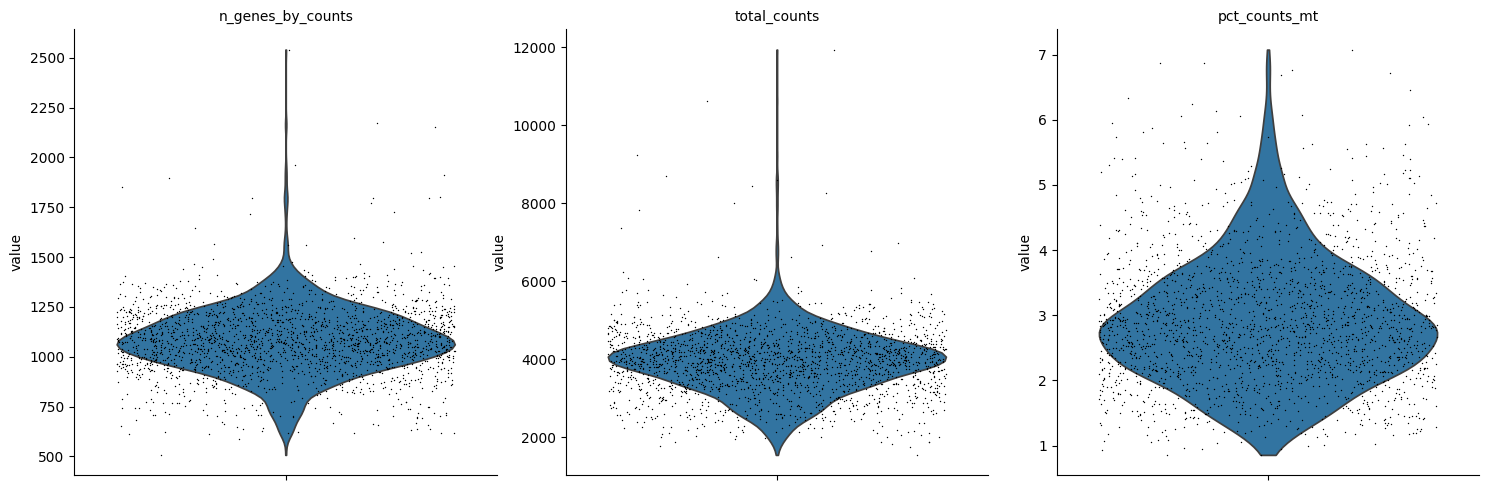

In [14]:
# ── QC violin plots — BEFORE filtering ───────────────────────────────────
# Use these plots to choose your thresholds below
sc.pl.violin(
    scdr,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter      = 0.4,
    multi_panel = True
)

In [15]:
# ── Apply QC thresholds ───────────────────────────────────────────────────
# Remove doublets: cells with unusually many detected genes
# 👇 Adjust threshold based on the upper tail in the violin plot above
scdr = scdr[scdr.obs.n_genes_by_counts < 2000, :].copy()
print(f"After doublet filter (<2000 genes): {scdr.n_obs:,} cells")

# Remove dying cells: high mitochondrial contamination
# 👇 Adjust — some tissues (heart, muscle) naturally have higher mt %
scdr = scdr[scdr.obs.pct_counts_mt < 5, :].copy()
print(f"After mt filter    (<5% mt):        {scdr.n_obs:,} cells × {scdr.n_vars:,} genes")

After doublet filter (<2000 genes): 2,138 cells
After mt filter    (<5% mt):        2,068 cells × 13,596 genes


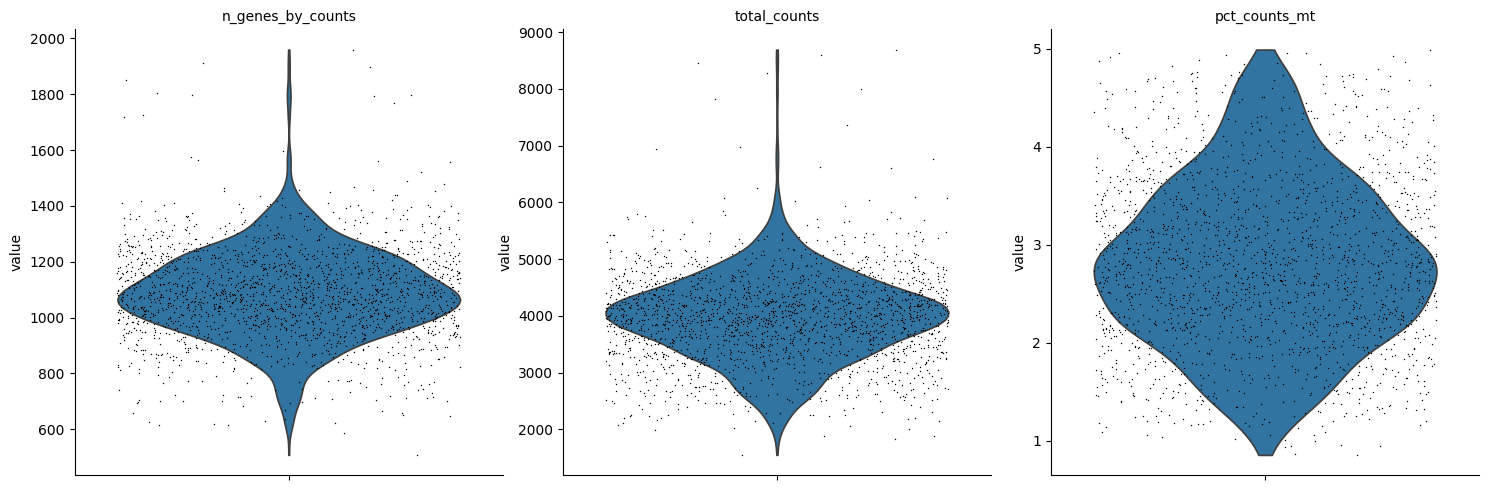

In [16]:
# ── QC violin plots — AFTER filtering (confirm improvement) ──────────────
sc.pl.violin(
    scdr,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter      = 0.4,
    multi_panel = True
)

---
## ⚗️ Section 5 — Preprocessing: Library Size, Normalisation & Log Transform

### Step-by-step logic

```
Raw counts
    ↓ normalize_total()   →  each cell sums to 10,000
    ↓ log1p()             →  log(x + 1) applied element-wise
Normalised log counts
```

### Why normalise?
Different cells are sequenced to different depths. A deeply-sequenced cell  
looks artificially "higher" for every gene.  Dividing by total counts per cell  
and rescaling to 10,000 ("counts per 10 k") makes cells comparable.

### Why log-transform?
After normalisation, values still range from 0 to ~10,000.  
A gene 10× more expressed shows as a difference of 9,000 — hard to handle  
statistically.  After `log1p`, the same 10× fold-change = ≈ 2.3 — much  
more manageable.  The `+1` prevents `log(0)` errors for zero-count genes.

> **Bug fixed (cells 17 & 19):** `scdr.X.todense()` is deprecated in  
> modern SciPy/NumPy. Replaced with `scdr.X.toarray()`.

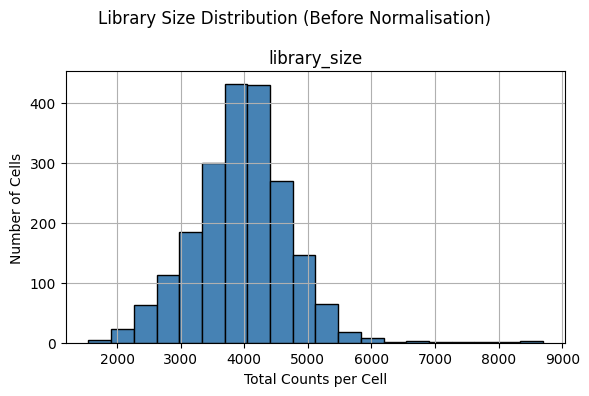

In [17]:
# ── Library size distribution (before normalisation) ─────────────────────
library_size = np.array(scdr.X.sum(axis=1)).flatten()
library_df   = pd.DataFrame(
    {'library_size': library_size},
    index = scdr.obs_names
)

ax = library_df.hist(bins=20, color='steelblue', edgecolor='black', figsize=(6, 4))
plt.suptitle('Library Size Distribution (Before Normalisation)')
plt.xlabel('Total Counts per Cell')
plt.ylabel('Number of Cells')
plt.tight_layout()
plt.show()

In [18]:
# ── Normalise: each cell → 10,000 total counts ───────────────────────────
sc.pp.normalize_total(scdr, target_sum=1e4)

# Verify: min and max should both be ~10,000
lib_post = np.array(scdr.X.sum(axis=1)).flatten()
print(f"Library size after normalisation — min: {lib_post.min():.1f}  max: {lib_post.max():.1f}")

normalizing counts per cell
    finished (0:00:06)
Library size after normalisation — min: 10000.0  max: 10000.0


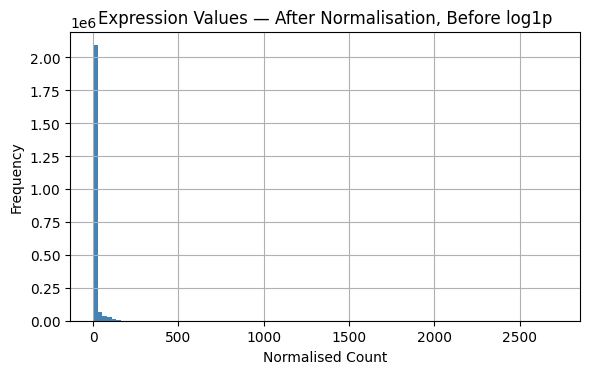

In [19]:
# ── Expression distribution BEFORE log transform ─────────────────────────
# FIX: .todense() is deprecated — replaced with .toarray()
if hasattr(scdr.X, 'toarray'):
    tmp = scdr.X.toarray().flatten()
else:
    tmp = np.asarray(scdr.X).flatten()

tmp = tmp[tmp > 0]   # show only expressed (non-zero) values
pd.DataFrame({'value': tmp}).hist(bins=100, color='steelblue', edgecolor='none', figsize=(6, 4))
plt.title('Expression Values — After Normalisation, Before log1p')
plt.xlabel('Normalised Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [20]:
# ── Log1p transformation: log(x + 1) ─────────────────────────────────────
sc.pp.log1p(scdr)

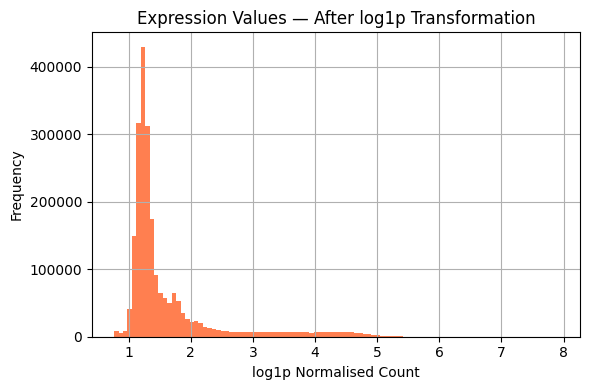

In [21]:
# ── Expression distribution AFTER log transform ──────────────────────────
# Should look more symmetric / bell-shaped compared to the previous histogram
# FIX: .todense() → .toarray()
if hasattr(scdr.X, 'toarray'):
    tmp = scdr.X.toarray().flatten()
else:
    tmp = np.asarray(scdr.X).flatten()

tmp = tmp[tmp > 0]
pd.DataFrame({'value': tmp}).hist(bins=100, color='coral', edgecolor='none', figsize=(6, 4))
plt.title('Expression Values — After log1p Transformation')
plt.xlabel('log1p Normalised Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

---
## 🎯 Section 6 — Highly Variable Genes & Scaling

### Why select highly variable genes (HVGs)?
Of ~14,700 genes, most are expressed at similar levels in every cell and carry  
no useful information for distinguishing cell types.  The **most variable**  
genes (high in some cells, low in others) are the informative ones.  
Keeping only ~2,000–3,000 HVGs:
- Speeds up PCA, clustering, and UMAP
- Reduces noise from uninformative genes

### Why scale?
Without scaling, a gene with average expression of 5,000 dominates PCA just  
because of its large numbers — not because it is biologically important.  
Scaling centres each gene to **mean = 0** and **std = 1**.  
`max_value=10` clips extreme outliers so no single cell dominates.

### The `.raw` snapshot
`scdr.raw = scdr.copy()` saves the normalised + log-transformed (but **not**  
scaled) data.  This snapshot is required later for:
- Differential expression testing
- Visualising expression on UMAP with correct colour scales

extracting highly variable genes
    finished (0:00:04)


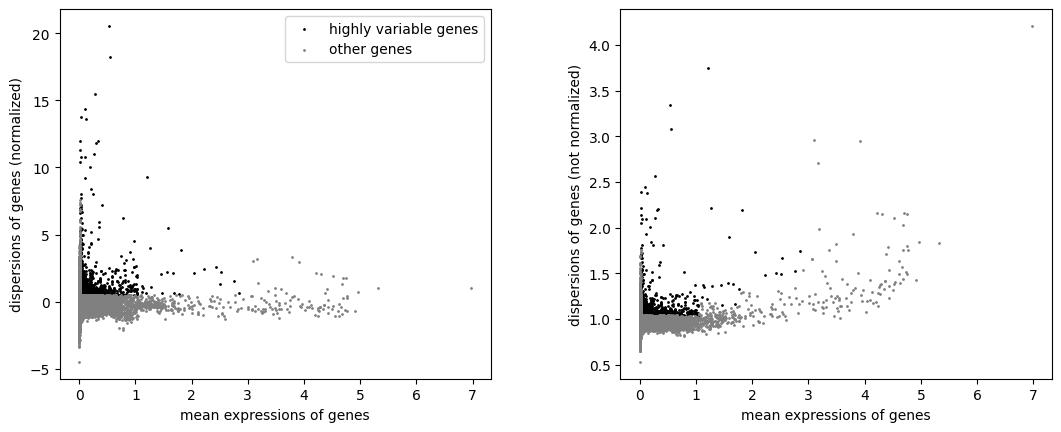

Highly variable genes: 1,815 / 13,596  (13.3 %)


In [22]:
# ── Identify highly variable genes ───────────────────────────────────────
sc.pp.highly_variable_genes(scdr)
sc.pl.highly_variable_genes(scdr)

# What fraction of genes are highly variable?
n_hvg = scdr.var.highly_variable.sum()
pct   = n_hvg / scdr.n_vars * 100
print(f"Highly variable genes: {n_hvg:,} / {scdr.n_vars:,}  ({pct:.1f} %)")

In [23]:
# ── Save pre-scaling snapshot as .raw ────────────────────────────────────
# This preserves normalised log counts before scaling distorts the values.
# Required for differential expression and UMAP gene-expression colouring.
scdr.raw = scdr.copy()

In [24]:
# ── Keep only highly variable genes ──────────────────────────────────────
scdr = scdr[:, scdr.var.highly_variable].copy()
print(f"After HVG selection: {scdr.n_obs:,} cells × {scdr.n_vars:,} genes")

After HVG selection: 2,068 cells × 1,815 genes


c:\Users\Lenovo\AppData\Local\Schrodinger\PyMOL2\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


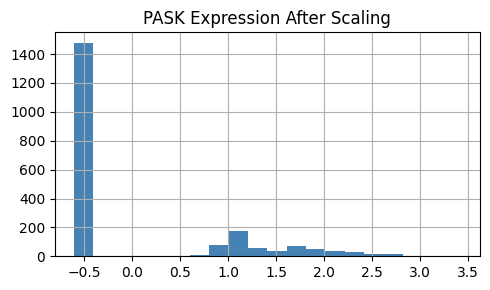

PASK — mean: 0.000  std: 1.000


In [25]:
# ── Scale the data: mean=0, std=1 per gene ───────────────────────────────
# max_value=10 clips extreme values so no single cell dominates PCA
sc.pp.scale(scdr, max_value=10)

# Verify scaling on one example gene (PASK)
# After scaling, mean ≈ 0 and std ≈ 1
if 'PASK' in scdr.var_names:
    pask_vals = scdr[:, 'PASK'].X.flatten()
    pd.DataFrame({'PASK': pask_vals}).hist(bins=20, color='steelblue', figsize=(5, 3))
    plt.title('PASK Expression After Scaling')
    plt.tight_layout()
    plt.show()
    print(f"PASK — mean: {pask_vals.mean():.3f}  std: {pask_vals.std():.3f}")
else:
    print("PASK not in dataset; skipping gene-level check.")

In [26]:
# ── Save preprocessed data to disk ───────────────────────────────────────
scdr.write_h5ad('scdr_preprocessed.h5ad')
print("Saved → scdr_preprocessed.h5ad")

Saved → scdr_preprocessed.h5ad


---
## 📉 Section 7 — PCA (Linear Dimensionality Reduction)

### Why PCA?
After selecting ~2,000 HVGs we still have 2,000 dimensions — impossible to  
visualise directly.  PCA compresses them into a ranked list of  
**principal components (PCs)**, each capturing a decreasing amount of variance.

### How many PCs to use?
Look at the **variance ratio plot** (scree plot).  Find the **"elbow"** —  
the point where adding more PCs gives diminishing returns.  Use that number  
as `n_pcs` in the next step.

```
Variance explained
    |●
    | ●
    |   ●
    |     ● ← elbow ≈ PC 15–20
    |        ● ● ● ● ...
    +─────────────────────
       PC1  PC10  PC30
```

### Scanpy module abbreviations
| Abbreviation | Module | Purpose |
|---|---|---|
| `sc.pp` | preprocessing | Filtering, normalisation, scaling |
| `sc.tl` | tools | PCA, clustering, UMAP, DE |
| `sc.pl` | plotting | All visualisations |

In [27]:
# ── Load preprocessed data (if running from here) ────────────────────────
scdr = sc.read_h5ad('scdr_preprocessed.h5ad')

# FIX: known Scanpy bug — reloading an h5ad file loses the log1p base entry,
#      causing a UserWarning in downstream steps.  Set it explicitly.
scdr.uns['log1p'] = {'base': None}
print(scdr)

AnnData object with n_obs × n_vars = 2068 × 1815
    obs: 'cell.type', 'cytokine.condition', 'donor.id', 'batch.10X', 'nGene', 'nUMI', 'percent.mito', 'S.Score', 'G2M.Score', 'Phase', 'cluster.id', 'effectorness', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'num_reads', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'


In [28]:
# ── Run PCA ───────────────────────────────────────────────────────────────
# svd_solver='arpack' is the recommended solver for sparse matrices
sc.tl.pca(scdr, svd_solver='arpack')

# Embeddings are stored automatically in scdr.obsm['X_pca']
print("PCA embedding shape:", scdr.obsm['X_pca'].shape)
print("  → rows = cells, columns = principal components")

computing PCA
    with n_comps=50
    finished (0:00:04)
PCA embedding shape: (2068, 50)
  → rows = cells, columns = principal components


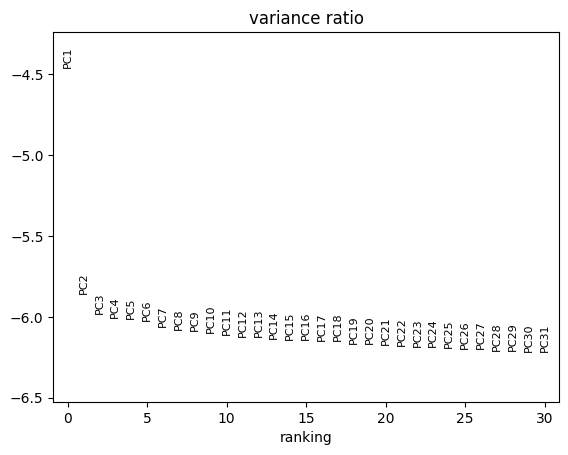

In [29]:
# ── Variance ratio plot (scree plot) ─────────────────────────────────────
# Each bar = % variance explained by that PC
# 👇 Find the elbow and use that number as n_pcs in sc.pp.neighbors() below
sc.pl.pca_variance_ratio(scdr, log=True)

---
## 🔗 Section 8 — Neighbourhood Graph, Leiden Clustering & UMAP

### The clustering pipeline
```
PCA embeddings
    ↓ sc.pp.neighbors()   →  build a k-nearest-neighbour graph
    ↓ sc.tl.leiden()      →  find densely connected communities (clusters)
    ↓ sc.tl.umap()        →  project the graph into 2D for visualisation
```

### Key parameters

| Parameter | Location | Default | Effect |
|-----------|----------|---------|--------|
| `n_pcs` | `sc.pp.neighbors` | `30` | PCs used — match elbow plot |
| `n_neighbors` | `sc.pp.neighbors` | `10` | Higher = smoother UMAP, less local detail |
| `resolution` | `sc.tl.leiden` | `1.0` | Higher = more clusters |

### ⚠️ UMAP caveat
- Cells **close together** → genuinely similar ✅  
- **Distance between clusters** → not reliably meaningful ❌  
- Re-running UMAP with different seeds gives different-looking layouts  
  (hence fixing `sc.settings.seed` at the top)

### Bug fixed — Leiden requires `resolution`
Scanpy ≥ 1.9 deprecated calling `sc.tl.leiden()` without an explicit  
`resolution` argument. Added `resolution=1.0` as the default.

In [30]:
# ── Build k-nearest-neighbour graph ──────────────────────────────────────
# 👇 Set n_pcs to the elbow value from the scree plot above
sc.pp.neighbors(scdr, n_neighbors=10, n_pcs=30)

computing neighbors
    using 'X_pca' with n_pcs = 30


c:\Users\Lenovo\AppData\Local\Schrodinger\PyMOL2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:01:08)


In [40]:
!{sys.executable} -m pip install ipywidgets igraph leidenalg

In [41]:
# ── Leiden clustering ─────────────────────────────────────────────────────
# FIX: Scanpy ≥ 1.9 requires an explicit resolution argument
# 👇 Increase resolution for more clusters, decrease for fewer
sc.tl.leiden(scdr, resolution=1.0)

print("Leiden cluster cell counts:")
print(scdr.obs['leiden'].value_counts().sort_index().to_string())

running Leiden clustering


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11824\3058132659.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(scdr, resolution=1.0)


    finished (0:00:00)
Leiden cluster cell counts:
leiden
0     231
1     231
2     205
3     182
4     176
5     171
6     148
7     130
8     123
9     120
10    118
11     97
12     76
13     60


computing UMAP
    finished (0:00:05)


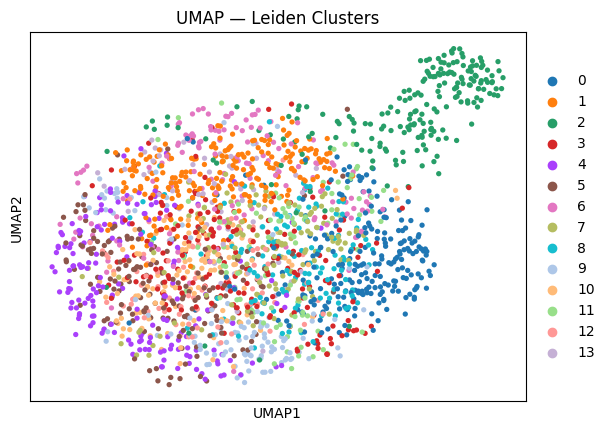

In [42]:
# ── Compute and visualise UMAP ────────────────────────────────────────────
sc.tl.umap(scdr)
sc.pl.umap(scdr, color='leiden', title='UMAP — Leiden Clusters')

---
## 🧪 Section 9 — Marker Gene Discovery

For each cluster, we find the genes that are **most specifically expressed**  
in that cluster compared to all others. These "marker genes" are how we  
identify what biological cell type each cluster represents.

### Why Wilcoxon instead of t-test?
The **t-test** assumes data follows a normal distribution — which  
single-cell expression data typically does **not**.  
The **Wilcoxon rank-sum test** makes no such assumption and is the  
community-standard recommendation for scRNA-seq.

> **Bug fixed:** changed `method='t-test'` → `method='wilcoxon'`

### Using the output
Look at the top 5–10 genes per cluster and search:
- [GeneCards](https://www.genecards.org/) — general gene function  
- [CellMarker 2.0](http://biocc.hrbmu.edu.cn/CellMarker/) — known cell-type markers  
- [PanglaoDB](https://panglaodb.se/) — automated cell type prediction

**Known T cell marker genes:**

| Marker genes | Cell type |
|---|---|
| `CCR7`, `SELL`, `TCF7`, `LEF1` | T Naive (TN) |
| `CCR7`, `IL7R`, `S100A4` | T Central Memory (TCM) |
| `GZMK`, `CCL5`, `EOMES` | T Effector Memory (TEM) |
| `GZMB`, `PRF1`, `KLRG1`, `CX3CR1` | TEMRA |

ranking genes
    finished (0:00:16)


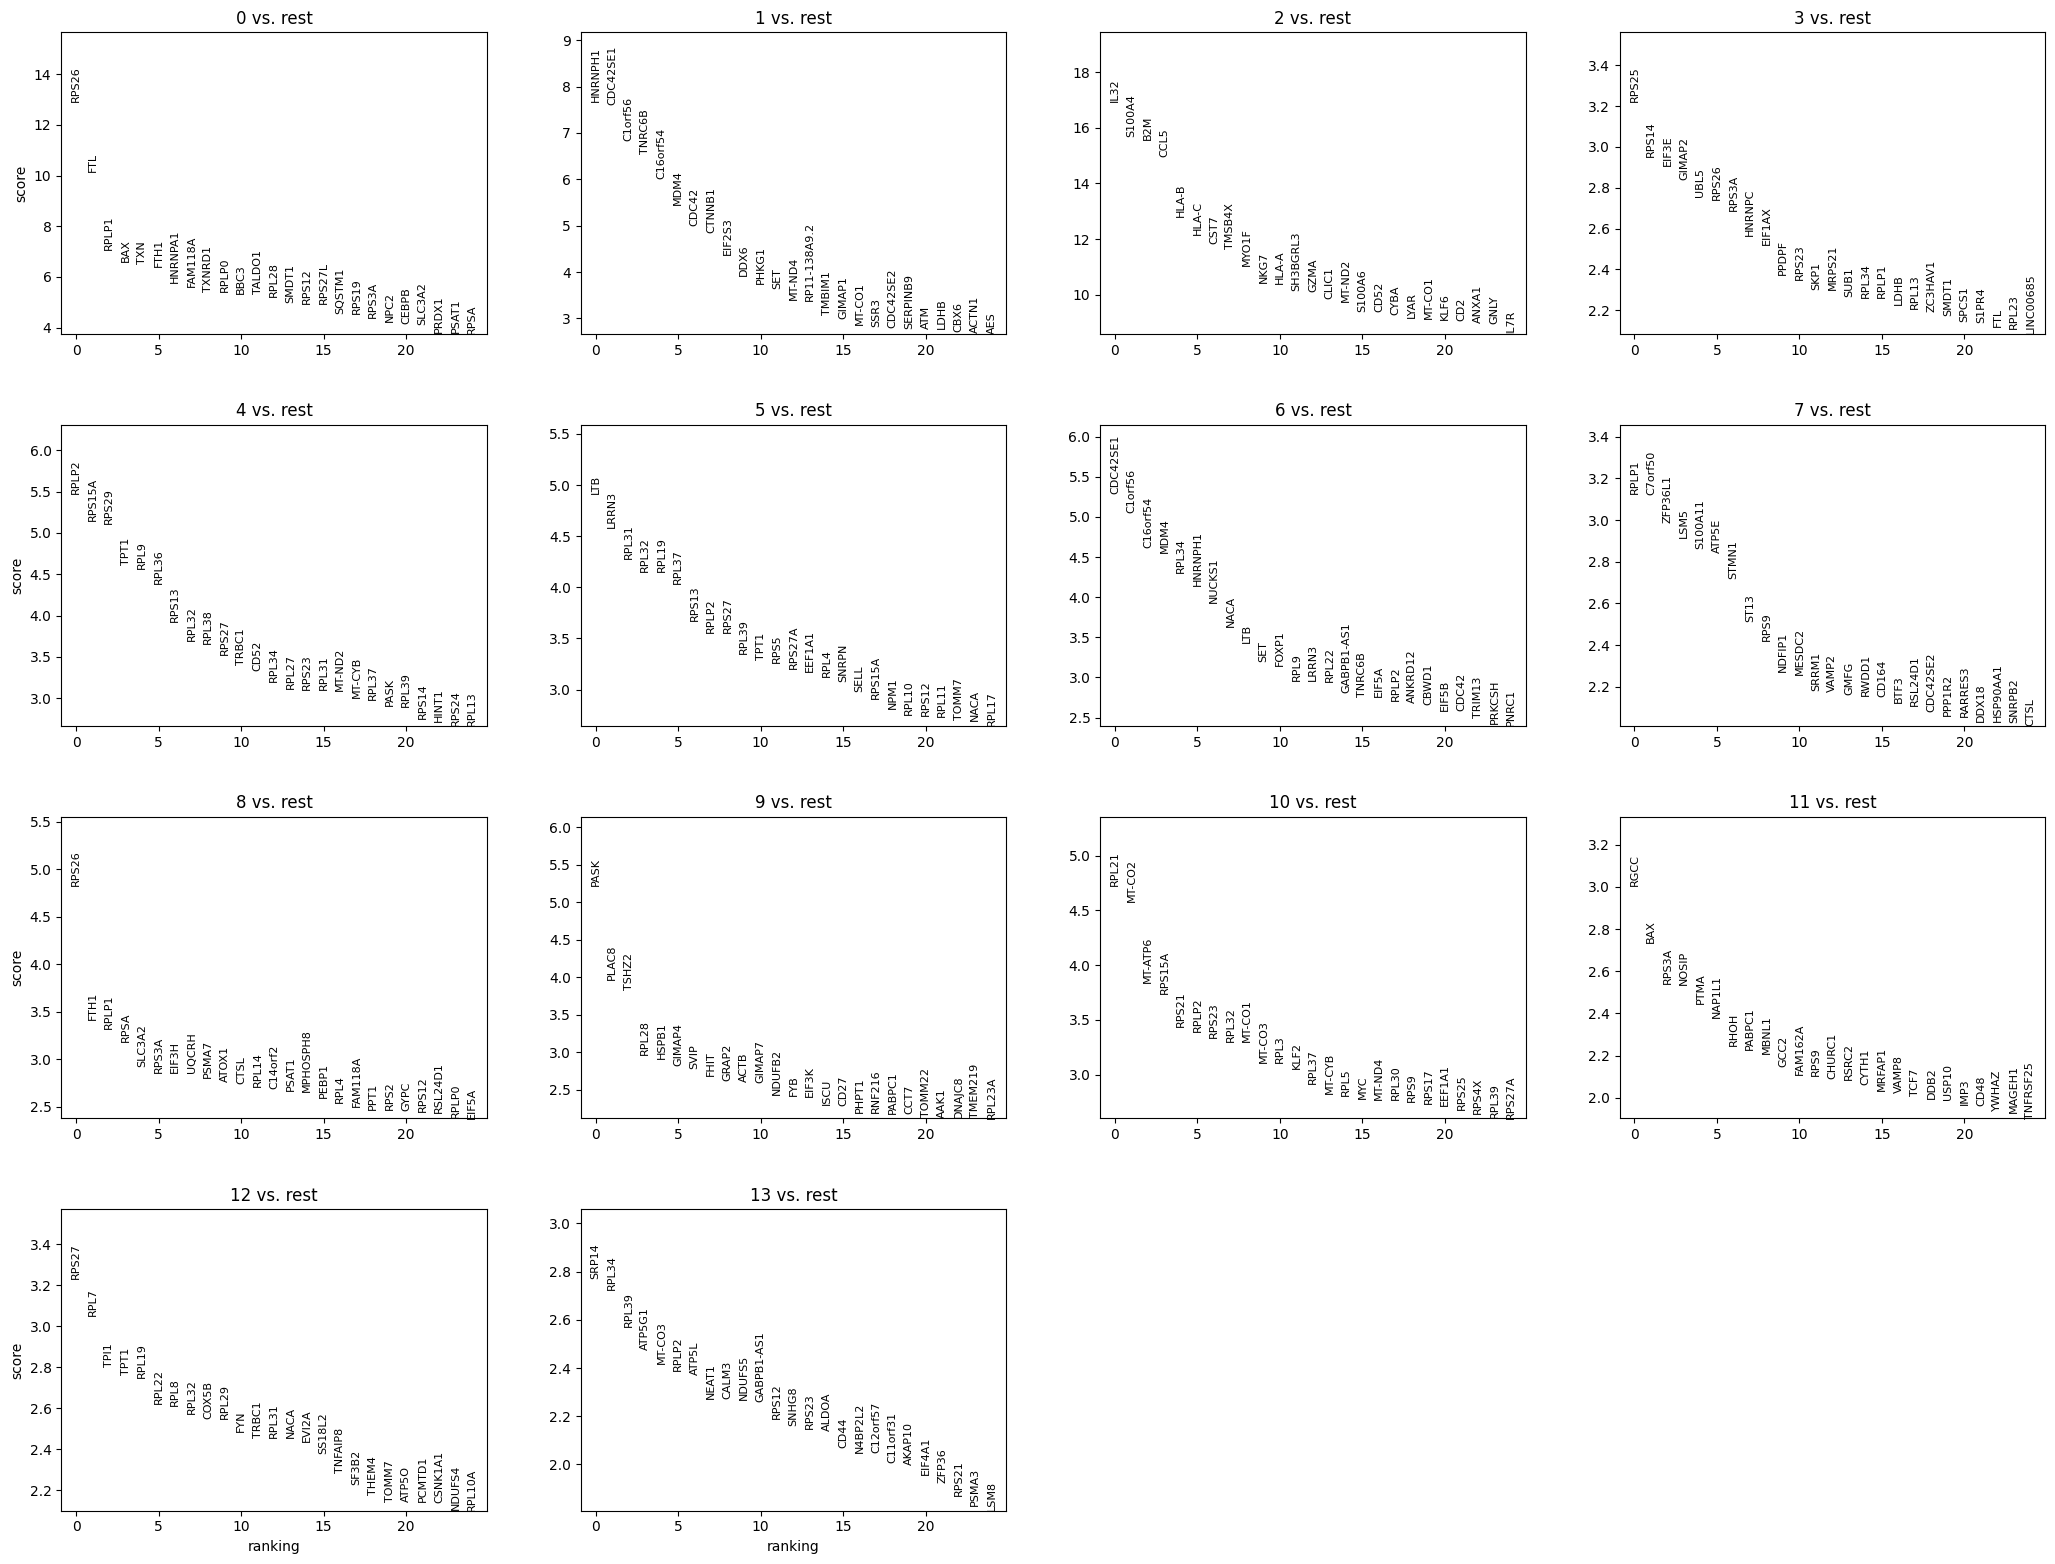

In [43]:
# ── Rank genes per cluster ────────────────────────────────────────────────
# FIX: method changed from 't-test' → 'wilcoxon'
#      Wilcoxon is non-parametric and better suited to scRNA-seq data
sc.tl.rank_genes_groups(scdr, 'leiden', method='wilcoxon')

# Plot the top 25 marker genes per cluster
sc.pl.rank_genes_groups(scdr, n_genes=25, sharey=False)

---
## 🏷️ Section 10 — Cell Type Annotation

Based on the marker genes above, we manually assign biological labels  
to each Leiden cluster.

### T cell subtypes in this dataset

| Label | Full name | Biology |
|-------|-----------|---------|
| `TN` | T Naive | Resting; have never encountered antigen |
| `TCM` | T Central Memory | Long-lived memory; recirculate in blood |
| `TEM` | T Effector Memory | Tissue-resident memory; rapid response |
| `TEMRA` | T Effector Memory RA | Terminally differentiated; cytotoxic |

### ⚠️ Important — cluster numbers change between runs!
Leiden cluster labels (0, 1, 2 …) are **not stable** across different  
parameter settings or runs without a fixed seed.  
Always **re-check your marker plots** before re-using these assignments.

### Bug fixed — chained `|` → `.isin()`
The original used verbose chained `|` conditions.  
`leiden.isin(['0','3','5'])` is cleaner and less error-prone.

In [44]:
# ── Initialise the cell_identity column ──────────────────────────────────
scdr.obs['cell_identity'] = 'Unassigned'

# ── Assign cluster 6 → TEMRA ──────────────────────────────────────────────
scdr.obs.loc[scdr.obs.leiden == '6', 'cell_identity'] = 'TEMRA'

In [45]:
# ── Assign remaining clusters based on marker genes ─────────────────────
# FIX: replaced chained | conditions with cleaner .isin() calls

# TN  — T Naive        (clusters 0, 3, 5)
scdr.obs.loc[scdr.obs.leiden.isin(['0', '3', '5']), 'cell_identity'] = 'TN'

# TCM — T Central Memory (clusters 1, 2)
scdr.obs.loc[scdr.obs.leiden.isin(['1', '2']), 'cell_identity'] = 'TCM'

# TEM — T Effector Memory (cluster 4)
scdr.obs.loc[scdr.obs.leiden == '4', 'cell_identity'] = 'TEM'

# ── Verification ──────────────────────────────────────────────────────────
print("Cell identity distribution:")
print(scdr.obs['cell_identity'].value_counts().to_string())

n_unassigned = (scdr.obs['cell_identity'] == 'Unassigned').sum()
if n_unassigned > 0:
    print(f"\n⚠️  WARNING: {n_unassigned} cells still 'Unassigned'")
    print("    → Check that cluster numbers match your leiden output above.")
else:
    print("\n✅ All cells assigned.")

Cell identity distribution:
cell_identity
Unassigned    724
TN            584
TCM           436
TEM           176
TEMRA         148

⚠️  WARNING: 724 cells still 'Unassigned'
    → Check that cluster numbers match your leiden output above.


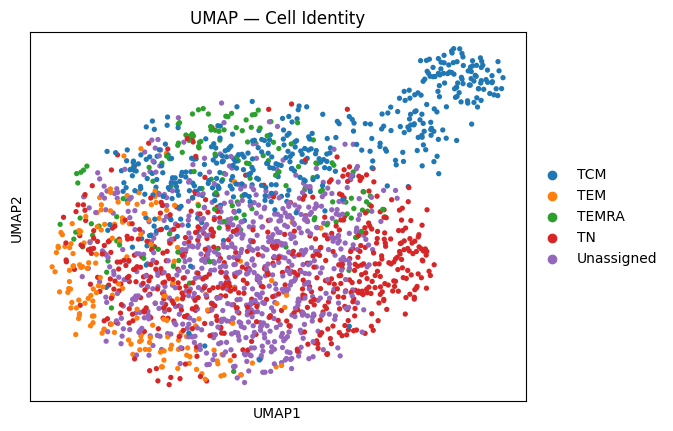

In [46]:
# ── UMAP coloured by cell identity ───────────────────────────────────────
sc.pl.umap(scdr, color='cell_identity', title='UMAP — Cell Identity')

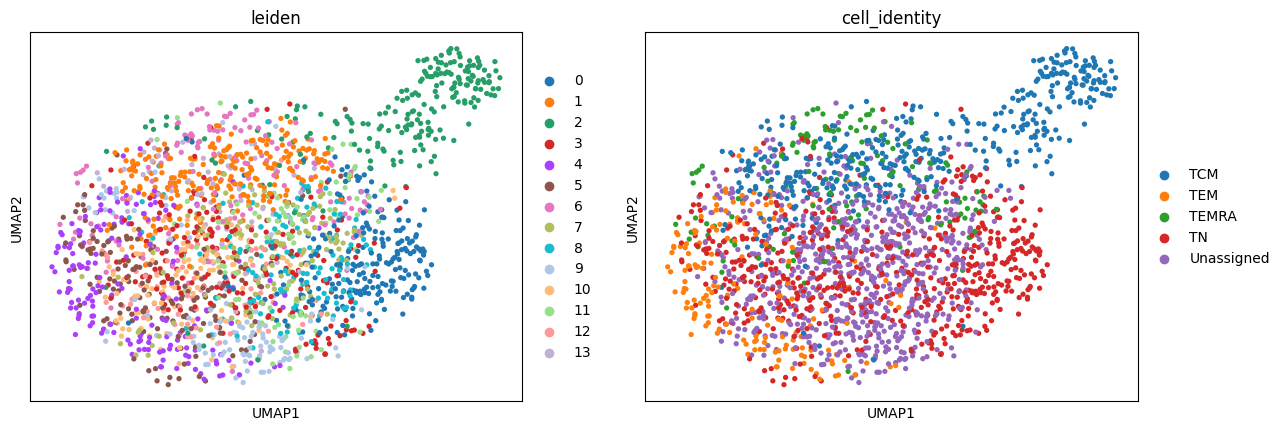

In [47]:
# ── Side-by-side: raw clusters vs annotated identity ─────────────────────
sc.pl.umap(
    scdr,
    color = ['leiden', 'cell_identity'],
    ncols = 2
)

---
## 💾 Section 11 — Save Results & Summary

### Final object contents
```
scdr
├── .X          scaled expression matrix (cells × HVGs)
├── .raw        normalised log counts (pre-scaling snapshot)
├── .obs        cell metadata including 'leiden' and 'cell_identity'
├── .var        gene metadata including 'highly_variable', 'mt'
├── .obsm       PCA + UMAP 2D coordinates
└── .uns        pipeline metadata (log1p, neighbours, leiden colours)
```

In [ ]:
# ── Final object summary ──────────────────────────────────────────────────
print(scdr)

In [ ]:
# ── Save annotated data ───────────────────────────────────────────────────
# Uncomment to write to disk
# scdr.write_h5ad('scdr_cell_classified.h5ad')
# print("Saved → scdr_cell_classified.h5ad")